# Experiment 03 — Encoding Strategies

**Research question:** Which quantum data encoding strategy performs best for particle physics classification?

We compare three strategies using 2 features / 2 layers / 5000 samples:

| Strategy | Description |
|----------|-------------|
| **Angle encoding** | Ry(xᵢ) — each feature maps to a rotation angle (paper default) |
| **Amplitude encoding** | Features encoded in the amplitudes of the quantum state |
| **Data reuploading** | Features are re-injected at each circuit layer |

In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.metrics import roc_auc_score

from utils.data_utils import load_higgs, binary_accuracy

np.random.seed(42)

# Shared hyperparameters
N_FEATURES = 2
N_LAYERS   = 2
N_EPOCHS   = 30
BATCH_SIZE = 32
LR         = 0.01

X_train, X_val, X_test, y_train, y_val, y_test = load_higgs(
    '../data/HIGGS.csv.gz',
    n_features=N_FEATURES,
    feature_indices=[4, 6],
    scale_range=(0, np.pi),
)

Dataset: 5000 samples | 2 features | train=3000, val=1000, test=1000


## Strategy A — Angle Encoding (paper baseline)

In [2]:
dev = qml.device('default.qubit', wires=N_FEATURES)

@qml.qnode(dev, interface='autograd')
def circuit_angle(weights, x):
    # Angle encoding
    for i in range(N_FEATURES):
        qml.RY(x[i], wires=i)
    # Model circuit
    for l in range(N_LAYERS):
        for q in range(N_FEATURES):
            qml.Rot(weights[l,q,0], weights[l,q,1], weights[l,q,2], wires=q)
        for q in range(N_FEATURES - 1):
            qml.CNOT(wires=[q, q+1])
        if N_FEATURES > 1:
            qml.CNOT(wires=[N_FEATURES-1, 0])
    return qml.expval(qml.PauliZ(0))

## Strategy B — Data Reuploading

Re-inject the input features at each layer (Pérez-Salinas et al., 2020). This increases expressibility without adding qubits.

In [3]:
@qml.qnode(dev, interface='autograd')
def circuit_reupload(weights, x):
    # Data reuploading: encode + rotate at each layer
    for l in range(N_LAYERS):
        # Re-encode data at each layer
        for i in range(N_FEATURES):
            qml.RY(x[i], wires=i)
        # Trainable rotation
        for q in range(N_FEATURES):
            qml.Rot(weights[l,q,0], weights[l,q,1], weights[l,q,2], wires=q)
        # Entanglement
        for q in range(N_FEATURES - 1):
            qml.CNOT(wires=[q, q+1])
        if N_FEATURES > 1:
            qml.CNOT(wires=[N_FEATURES-1, 0])
    return qml.expval(qml.PauliZ(0))

## Strategy C — Amplitude Encoding

Encode features as amplitudes of the quantum state using `qml.AmplitudeEmbedding`.
Requires normalisation; uses 1 qubit for 2 features.

In [4]:
# Amplitude encoding needs normalised input; uses ceil(log2(n_features)) qubits
# For 2 features we need 1 qubit but that's too few for CNOT — we pad to 4 features / 2 qubits
dev_amp = qml.device('default.qubit', wires=N_FEATURES)

@qml.qnode(dev_amp, interface='autograd')
def circuit_amplitude(weights, x):
    # Amplitude encoding (normalised input)
    norm = pnp.sqrt(pnp.dot(x, x) + 1e-8)
    x_norm = pnp.array([x[0]/norm, x[1]/norm, 0.0, 0.0])  # pad to 2^N_FEATURES
    qml.AmplitudeEmbedding(x_norm, wires=range(N_FEATURES), normalize=False)
    # Model circuit
    for l in range(N_LAYERS):
        for q in range(N_FEATURES):
            qml.Rot(weights[l,q,0], weights[l,q,1], weights[l,q,2], wires=q)
        for q in range(N_FEATURES - 1):
            qml.CNOT(wires=[q, q+1])
        if N_FEATURES > 1:
            qml.CNOT(wires=[N_FEATURES-1, 0])
    return qml.expval(qml.PauliZ(0))

## Shared Training Function

In [5]:
def train_and_eval(circuit_fn, name):
    print(f'\nTraining: {name}')
    np.random.seed(42)
    weights = pnp.array(
        np.random.uniform(0, 2*np.pi, (N_LAYERS, N_FEATURES, 3)),
        requires_grad=True
    )
    bias = pnp.array(0.0, requires_grad=True)
    opt = qml.AdamOptimizer(stepsize=LR)

    train_losses, val_losses = [], []

    for epoch in range(N_EPOCHS):
        perm = np.random.permutation(len(X_train))
        Xs, ys = X_train[perm], y_train[perm]
        for start in range(0, len(Xs), BATCH_SIZE):
            Xb = Xs[start:start+BATCH_SIZE]
            yb = ys[start:start+BATCH_SIZE].astype(float)
            def cost(w, b):
                preds = pnp.array([circuit_fn(w, x) + b for x in Xb])
                return pnp.mean((yb - preds) ** 2)
            weights, bias = opt.step(cost, weights, bias)

        def loss_fn(X, y):
            preds = pnp.array([circuit_fn(weights, x) + bias for x in X])
            return float(pnp.mean((y.astype(float) - preds) ** 2))

        train_losses.append(loss_fn(X_train, y_train))
        val_losses.append(loss_fn(X_val, y_val))

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:2d} | train={train_losses[-1]:.4f}, val={val_losses[-1]:.4f}')

    # Test evaluation
    test_raw = np.array([float(circuit_fn(weights, x) + bias) for x in X_test])
    test_acc = binary_accuracy(y_test, test_raw)
    y01 = (y_test == 1).astype(int)
    score = (test_raw - test_raw.min()) / (test_raw.max() - test_raw.min() + 1e-8)
    test_auc = roc_auc_score(y01, score)

    print(f'  → Test Acc: {test_acc:.4f} | AUC: {test_auc:.4f}')
    return {'train_losses': train_losses, 'val_losses': val_losses,
            'test_acc': test_acc, 'test_auc': test_auc}

In [6]:
results = {
    'Angle encoding':      train_and_eval(circuit_angle,     'Angle encoding'),
    'Data reuploading':    train_and_eval(circuit_reupload,  'Data reuploading'),
    'Amplitude encoding':  train_and_eval(circuit_amplitude, 'Amplitude encoding'),
}


Training: Angle encoding
  Epoch 10 | train=0.9832, val=0.9812
  Epoch 20 | train=0.9853, val=0.9844
  Epoch 30 | train=0.9830, val=0.9809
  → Test Acc: 0.5750 | AUC: 0.5709

Training: Data reuploading
  Epoch 10 | train=0.9841, val=0.9822
  Epoch 20 | train=0.9853, val=0.9842
  Epoch 30 | train=0.9833, val=0.9812
  → Test Acc: 0.5740 | AUC: 0.5709

Training: Amplitude encoding
  Epoch 10 | train=0.9899, val=0.9902
  Epoch 20 | train=0.9902, val=0.9910
  Epoch 30 | train=0.9897, val=0.9897
  → Test Acc: 0.5670 | AUC: 0.5547



Encoding Strategy Comparison
Strategy                    Test Acc   Test AUC
------------------------------------------------
Angle encoding                0.5750     0.5709
Data reuploading              0.5740     0.5709
Amplitude encoding            0.5670     0.5547


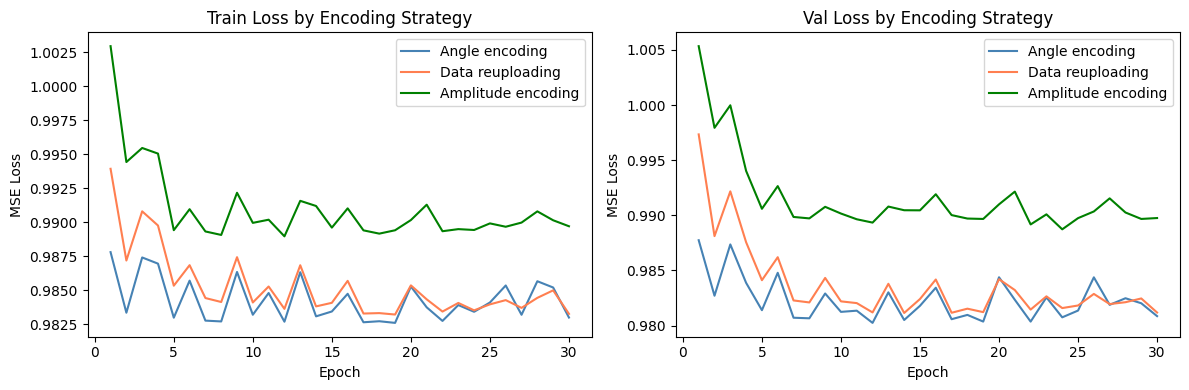

In [7]:
# --- Summary ---
print('\nEncoding Strategy Comparison')
print(f'{"Strategy":<25} {"Test Acc":>10} {"Test AUC":>10}')
print('-' * 48)
for name, r in results.items():
    print(f'{name:<25} {r["test_acc"]:>10.4f} {r["test_auc"]:>10.4f}')

# --- Loss curves ---
epochs = range(1, N_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['steelblue', 'coral', 'green']

for (name, r), c in zip(results.items(), colors):
    axes[0].plot(epochs, r['train_losses'], label=name, color=c)
    axes[1].plot(epochs, r['val_losses'],   label=name, color=c)

axes[0].set_title('Train Loss by Encoding Strategy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[1].set_title('Val Loss by Encoding Strategy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE Loss')
axes[1].legend()
plt.tight_layout()
plt.savefig('../figures/03_encoding_strategies.png', dpi=150)
plt.show()